In [22]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [23]:
df=pd.read_csv('house_prices.csv')
df.head()

,area,rooms,price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


In [24]:
df.shape

(47, 3)

In [25]:
df.info

<bound method DataFrame.info of     area  rooms   price
0   2104      3  399900
1   1600      3  329900
2   2400      3  369000
3   1416      2  232000
4   3000      4  539900
5   1985      4  299900
6   1534      3  314900
7   1427      3  198999
8   1380      3  212000
9   1494      3  242500
10  1940      4  239999
11  2000      3  347000
12  1890      3  329999
13  4478      5  699900
14  1268      3  259900
15  2300      4  449900
16  1320      2  299900
17  1236      3  199900
18  2609      4  499998
19  3031      4  599000
20  1767      3  252900
21  1888      2  255000
22  1604      3  242900
23  1962      4  259900
24  3890      3  573900
25  1100      3  249900
26  1458      3  464500
27  2526      3  469000
28  2200      3  475000
29  2637      3  299900
30  1839      2  349900
31  1000      1  169900
32  2040      4  314900
33  3137      3  579900
34  1811      4  285900
35  1437      3  249900
36  1239      3  229900
37  2132      4  345000
38  4215      4  549000
39  2162

In [26]:
x=df.iloc[:,0:1]
x

,area
0,2104
1,1600
2,2400
3,1416
4,3000
5,1985
6,1534
7,1427
8,1380
9,1494


In [27]:
y=df.iloc[:,-1]
y

0     399900
1     329900
2     369000
3     232000
4     539900
5     299900
6     314900
7     198999
8     212000
9     242500
10    239999
11    347000
12    329999
13    699900
14    259900
15    449900
16    299900
17    199900
18    499998
19    599000
20    252900
21    255000
22    242900
23    259900
24    573900
25    249900
26    464500
27    469000
28    475000
29    299900
30    349900
31    169900
32    314900
33    579900
34    285900
35    249900
36    229900
37    345000
38    549000
39    287000
40    368500
41    329900
42    314000
43    299000
44    179900
45    299900
46    239500
Name: price, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split

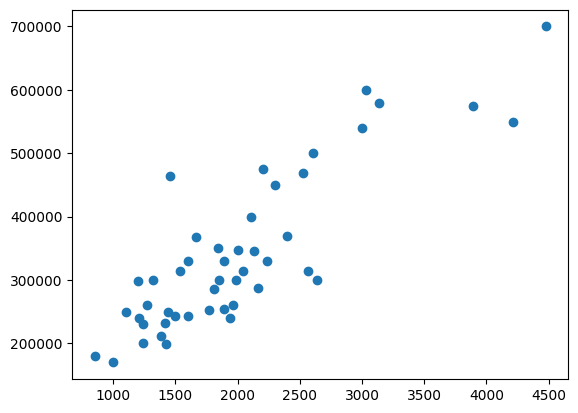

In [29]:
plt.scatter(x,y)

In [30]:
x_train, x_test, y_train, y_test =train_test_split(x,y,test_size=0.2, random_state=0)

In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
model=LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
model.predict([[3100],[2500],[4000]])

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([474748.67527295, 399688.01858985, 587339.6602976 ])

In [34]:
y_pred=model.predict(x_test)
y_pred[0:5]

array([362157.6902483 , 479377.41576841, 316996.19514397, 462238.56582577,
       413324.03788728])

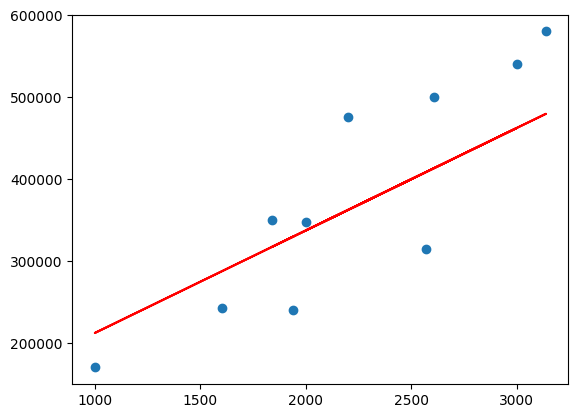

In [35]:
plt.plot(x_test, y_pred, color='red')
plt.scatter(x_test, y_test)

In [36]:
error = y_pred-y_test
error

28   -112842.309752
33   -100522.584232
30    -32903.804856
4     -77661.434174
18    -86673.962113
11     -9862.528646
42     94069.791919
31     42136.376882
22     44697.437943
10     89632.405686
Name: price, dtype: float64

In [37]:
from sklearn.metrics import r2_score
r2=r2_score(y_test, y_pred)
r2

0.6723239162245208

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 69100.26362026193
RMSE: 76300.8583428132
